In [1]:
# import os
import re
from tqdm import tqdm
import time
import json
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import torch
import torch.nn as nn
from scipy.stats import mode
import torch.optim as optim
from torch.utils.data import DataLoader
# from pthPontos.MyNetwork import getModel
import random
# Caminho absoluto para a pasta 'src' (ajuste conforme sua estrutura)
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
from scripts.calculos import Globo
# Adiciona ao sys.path
sys.path.append(src_path)

from datasets.weedsgalore.weedsgalore import WeedsGaloreDataset
from nets import deeplabv3plus_resnet50
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassCalibrationError, MulticlassConfusionMatrix

json_path = r'via_export_json.json'
root_images = r'imagens'
leitura = 'r'
imagens_path = r'data/nao_temporal/images'
semantic_path = r'data/nao_temporal/semantics'


In [2]:
def getPoligonos():
    with open(json_path,'r') as json_file:
        return [image for key,image in json.load(json_file).items() if image['regions']]
print(type(getPoligonos()[0]))

<class 'dict'>


In [3]:
def limparData():
    try:
        shutil.rmtree(imagens_path)
        shutil.rmtree(semantic_path)
    except Exception as e:
        print('Erro ao deletar Dataset',e)

In [4]:
def createRGB(list):
    # imagens_path
    # root_images
    os.makedirs(imagens_path)
    for image in list:
        image_actual = os.path.join(root_images,image)
        if (actual_image := cv2.imread(image_actual,cv2.IMREAD_COLOR)) is None:
            raise FileNotFoundError(f"Não foi possível ler a imagem: {image_actual}")
        B,G,R = cv2.split(actual_image)
        R_path = os.path.join(imagens_path,image.replace('.png','_R.png'))
        G_path = os.path.join(imagens_path,image.replace('.png','_G.png'))
        B_path = os.path.join(imagens_path,image.replace('.png','_B.png'))
        cv2.imwrite(R_path,R)
        cv2.imwrite(G_path,G)
        cv2.imwrite(B_path,B)


In [5]:

def getObj(name, images):
    for image in images:
        if image['filename'] == name:
            return image
    return None

def createSemantics(file_list, images):
    os.makedirs(semantic_path, exist_ok=True)

    for name in file_list:
        fundo = 0
        image_path = os.path.join(root_images, name)
        actual_image = cv2.imread(image_path, cv2.IMREAD_COLOR)

        if actual_image is None:
            raise FileNotFoundError(f"Não foi possível ler a imagem: {image_path}")
        
        semantic = np.zeros((600, 600), dtype=np.uint8)
        poligons = getObj(name, images)

        if poligons is None:
            print(f"Aviso: '{name}' não possui regiões definidas.")
            continue

        for poligon in poligons.get('regions', []):
            tipo = poligon["region_attributes"].get("type", "")
            classe = 1 if tipo == "Milho" else 2 if tipo == "Daninha" else 0

            all_points_x = poligon["shape_attributes"]["all_points_x"]
            all_points_y = poligon["shape_attributes"]["all_points_y"]
            region = np.column_stack((all_points_x, all_points_y))

            mask = np.zeros((600, 600), dtype=np.uint8)
            cv2.fillPoly(mask, [region], 1)

            ys, xs = np.where(mask == 1)
            pixels = actual_image[ys, xs]

            if len(pixels) == 0:
                continue

            # Cria o globo com os pixels da região
            try:
                globo = Globo(*[p.astype(np.float32) for p in pixels])
            except Exception as e:
                print(f"Erro ao criar globo: {e}")
                continue
            print(type(globo))
            centro = globo.centro()
            distancia_maxima = 20

            # Calcula a distância de cada pixel até o centro
            diffs = pixels.astype(np.float32) - centro
            distancias = np.linalg.norm(diffs, axis=1)

            dentro = distancias <= distancia_maxima
            fora   = ~dentro

            ys_valid = ys[dentro]
            xs_valid = xs[dentro]
            ys_fora = ys[fora]
            xs_fora = xs[fora]

            # Preenche toda a região com fundo
            cv2.fillPoly(semantic, [region], fundo)
            # Pinta os que estão dentro da distância permitida
            semantic[ys_valid, xs_valid] = classe
            # Os que estão fora, mantém o fundo (opcional, já está pintado como fundo)

        output_path = os.path.join(semantic_path, name)
        cv2.imwrite(output_path, semantic)

In [7]:
def atualizetxts():

# Lista os arquivos PNG e remove a extensão
    data = [img.replace('.png', '') for img in os.listdir('./data/nao_temporal/semantics') if img.endswith('.png')]
    print(data)
    def divide(datas, test=15, val=15, train=70):
        total = test + val + train
        testPorcent = test / total
        valPorcent = val / total
        total_test = int(testPorcent * len(datas))
        total_val = int(valPorcent * len(datas))
        return datas[:total_test], datas[total_test:total_test + total_val], datas[total_test + total_val:]

# Divide os dados
    test, val, train = divide(data)
    print(len(test)+len(val)+len(train))
    print('test:',test)
    print('val:',val)
    print('train:',train)
# Escreve nos arquivos corretamente
    with open(r'src\datasets\weedsgalore\splits\test.txt', 'w') as testDoc:
        testDoc.write('\n'.join(test))

    with open(r'src\datasets\weedsgalore\splits\val.txt', 'w') as valDoc:
        valDoc.write('\n'.join(val))

    with open(r'src\datasets\weedsgalore\splits\train.txt', 'w') as trainDoc:
        trainDoc.write('\n'.join(train))
# atualizetxts()


In [6]:
def atualizeDataset():
    limparData()
    images = getPoligonos()
    print(images)
    image_names = [image_name['filename'] for image_name in images]
    createRGB(image_names)
    createSemantics(image_names,images)
    atualizetxts()

    

In [ ]:
def exemple(img = 0):
    semantics_names = [img for img in os.listdir(r'data\nao_temporal\semantics') if img.endswith('.png')]
    semantic = semantics_names[img]
    semantic_path_img = os.path.join(semantic_path,semantic)
    image = cv2.imread(semantic_path_img,cv2.IMREAD_GRAYSCALE)
    plt.imshow(image,cmap='gray')

In [9]:
atualizeDataset()
exemple()

[{'filename': '2_image.png', 'size': 1017433, 'regions': [{'shape_attributes': {'name': 'polygon', 'all_points_x': [33, 21, 9, 2, 3, 15], 'all_points_y': [49, 38, 27, 20, 52, 46]}, 'region_attributes': {'type': 'Milho'}}, {'shape_attributes': {'name': 'polygon', 'all_points_x': [47, 32, 28, 37, 64, 78, 89, 102, 121, 124, 105, 124, 126, 109, 87, 83, 76, 64, 58], 'all_points_y': [83, 81, 63, 58, 59, 56, 44, 43, 31, 37, 59, 50, 60, 73, 73, 87, 91, 90, 83]}, 'region_attributes': {'type': 'Milho'}}, {'shape_attributes': {'name': 'polygon', 'all_points_x': [42, 54, 62, 72, 71, 81, 91, 83, 74, 65, 53, 47, 36, 27, 15, 10, 22, 22, 12, 23, 31, 49, 56, 41, 36], 'all_points_y': [183, 174, 161, 156, 140, 153, 146, 134, 118, 109, 99, 90, 87, 84, 77, 91, 106, 120, 118, 138, 132, 130, 139, 159, 169]}, 'region_attributes': {'type': 'Milho'}}, {'shape_attributes': {'name': 'polygon', 'all_points_x': [11, 16, 13, 22, 14, 8, 1, 2], 'all_points_y': [169, 155, 140, 139, 130, 111, 110, 163]}, 'region_attribu

KeyboardInterrupt: 

In [ ]:
exemple()

In [14]:
def get_lenData(data):
    data_path = r'src\datasets\weedsgalore\splits\DATA.txt'.replace('DATA',data)
    with open(data_path,'r') as file:
        return len(file.read().split('\n'))
   
print(get_lenData('val'))

1


In [15]:
modelo_inicial = r'pthPontos\dlv3p_rgb_3.pth'
def actual_model():
    modelos = [m for m in os.listdir('pthPontos') if m.endswith('.pth')]
    if 'dlv3p_rgb_3.pth' in modelos:
        modelos.remove('dlv3p_rgb_3.pth')
    
    if not modelos:
        return None  # Nenhum modelo válido encontrado

    # Extrai o número antes do underscore para ordenar corretamente
    modelos.sort(key=lambda nome: int(nome.split('_')[0]))
    maior = modelos[-1]  # Último da lista ordenada numericamente
    return os.path.join('pthPontos', maior)
    

    return modelo_inicial if sem_outro else maior
def proximoModelo():
    if actual_model() == modelo_inicial:
        return os.path.join('./pthPontos','0_modelo_treinado.pth')
    else:
        nova_vercao = int(actual_model().split('\\')[1].split('_')[0])+1
        novo_modelo = f'{nova_vercao}_modelo_treinado.pth'
        return os.path.join('./pthPontos',novo_modelo)
    
print('modelo usado: ',actual_model())
print('proximo modelo:',proximoModelo())

modelo usado:  pthPontos\110_modelo_treinado.pth
proximo modelo: ./pthPontos\111_modelo_treinado.pth


In [16]:
dataset_path = r'data\nao_temporal'
dataset_size = get_lenData('train')
# dataset_size = None
in_bands = 3
num_classes = 3
is_training = True
split = 'train'
augmentation = True
dataset = WeedsGaloreDataset( dataset_path, dataset_size, in_bands, num_classes, is_training, split, augmentation)
print(dataset.__len__())
# print(dataset.__getitem__(51))

7


In [17]:
def plotImagens(images, semantics, predicts):
    num_images = len(images)
    fig, axes = plt.subplots(num_images, 3, figsize=(9, 3 * num_images))

    if num_images == 1:
        axes = [axes]  # Garante que axes seja iterável mesmo para um único item

    for i in range(num_images):
        img = images[i].squeeze(0).permute(1, 2, 0).cpu().numpy()  # Remove batch e ajusta dimensões
        label = semantics[i]  # Já é um NumPy array, então não precisa de .numpy()
        predict = torch.argmax(predicts[i], dim=1).squeeze(0).cpu().numpy()  # Corrige dimensão da previsão

        axes[i][0].imshow(img)
        axes[i][0].set_title("Imagem")
        axes[i][0].axis("off")

        axes[i][1].imshow(label, cmap='gray')
        axes[i][1].set_title("Rótulo")
        axes[i][1].axis("off")

        axes[i][2].imshow(predict, cmap='gray')
        axes[i][2].set_title("Previsão")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()

In [18]:
num_classes = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use: {device.type}')
model = deeplabv3plus_resnet50(num_classes=num_classes)
model = model.to(device)

model.backbone.conv1 = nn.Conv2d(num_classes,model.backbone.conv1.out_channels,kernel_size=7,stride=2,padding=3,bias=False,device=device)

model_weights_dir = actual_model()
model_dict = torch.load(model_weights_dir,map_location=device)
model.load_state_dict(model_dict)

# dataset
dataloader = DataLoader(dataset=dataset,batch_size=4,shuffle=False,num_workers=1,collate_fn=None, drop_last=True)
data_iter = iter(dataloader)

evaluator = MulticlassJaccardIndex(num_classes=num_classes,average=None,ignore_index=None).to(device)

confmat = MulticlassConfusionMatrix(num_classes=num_classes, normalize='true', ignore_index=None).to(device)

model.eval()

Device in use: cpu


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [28]:

images = []
semantics = []
predicts = []
model.eval()
for idx in random.sample(range(get_lenData('train')), 3):
    img, label, _ = dataset.__getitem__(idx)

    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # Adiciona batch dim
    print('type entrada:',type(img))

    print(img.shape)
    predict = model(img).detach()  # Garante que não há gradientes ativos
    
    images.append(img)
    semantics.append(label)
    predicts.append(predict)


type entrada: <class 'torch.Tensor'>
torch.Size([1, 3, 600, 600])
type entrada: <class 'torch.Tensor'>
torch.Size([1, 3, 600, 600])
type entrada: <class 'torch.Tensor'>
torch.Size([1, 3, 600, 600])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14693186..1.1263006].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.030479437..1.1279944].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12745547..1.1079173].


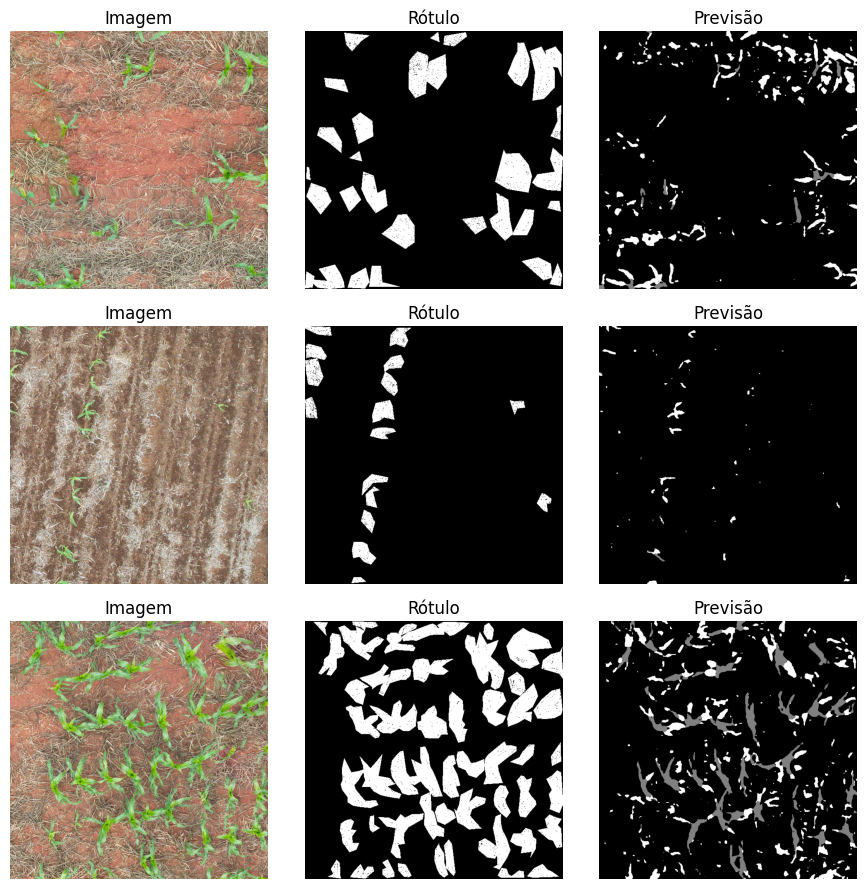

In [29]:
plotImagens(images, semantics, predicts)

In [ ]:
def ajustarImages():
    rgb_path = 'data/rgb'
    rootatual = 'data/images'
    os.makedirs(rgb_path, exist_ok=True) 
    for image_path,image_name in [(os.path.join(rootatual,image_name),image_name) for image_name in os.listdir(rootatual) if image_name.endswith('png')]:
        image = cv2.imread(image_path,cv2.IMREAD_COLOR_RGB)
        r,g,b = cv2.split(image)
        print(cv2.imwrite(os.path.join(rgb_path,image_name.replace('image.','image_R.')),r))
        cv2.imwrite(os.path.join(rgb_path,image_name.replace('image.','image_G.')),g)
        cv2.imwrite(os.path.join(rgb_path,image_name.replace('image.','image_B.')),b)
# ajustarImages()

* Criando dataset/dataloader de validacao 

In [ ]:
dataset_path = r'data\nao_temporal'
dataset_size = get_lenData('val')
# dataset_size = None
in_bands = 3
num_classes = 3
is_training = False
split = 'val'
augmentation = True
dataset_val = WeedsGaloreDataset( dataset_path, dataset_size, in_bands, num_classes, is_training, split, augmentation)
num_classes = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use: {device.type}')
model = deeplabv3plus_resnet50(num_classes=num_classes)
model = model.to(device)

model.backbone.conv1 = nn.Conv2d(num_classes,model.backbone.conv1.out_channels,kernel_size=7,stride=2,padding=3,bias=False,device=device)

model_weights_dir = actual_model()
model_dict = torch.load(model_weights_dir,map_location=device)
model.load_state_dict(model_dict)

# dataset
dataloader_val = DataLoader(dataset=dataset_val,batch_size=4,shuffle=False,num_workers=1,collate_fn=None, drop_last=True)
# dataset_iter = iter(dataset)
# dataset_val_iter = iter(dataset_val)
# mcce = MulticlassCalibrationError(num_classes=3, n_bins=3, norm='l1', ignore_index=None).to(device)
mcce = MulticlassCalibrationError(num_classes=3, n_bins=3, norm='l1', ignore_index=0).to(device)


Device in use: cpu


In [ ]:
def train(dataset_iter, device, net, evaluator, mcce, confmat):
    net.eval()
    for i, data in enumerate(dataset_iter):
        features, unique_labels, binary_labels = data
        features, unique_labels, binary_labels = (
            torch.tensor(features,dtype=torch.float32).to(device).unsqueeze(0),
            torch.tensor(unique_labels,dtype=torch.long).to(device),
            torch.tensor(binary_labels,dtype=torch.long).to(device),
        )
        labels = binary_labels
        # print("Formato da entrada:", features.shape)
        # print('type entrada:',type(features))
        # Forward pass
        out = net(features).detach()
        out = torch.nn.functional.softmax(out, dim=1)
        _, pred = torch.max(out, 1)

        # Atualiza métricas
        # print(f"Preds shape: {pred.shape}, Target shape: {labels.shape}")
        # evaluator.update(out.squeeze(0), labels)
        labels = labels.unsqueeze(0)
        evaluator.update(pred, labels)
        scene_scores = evaluator(pred, labels)
        mcce.update(out, labels)
        confmat.update(pred, labels)
    
    return scene_scores, net  # Retorna as métricas e o modelo atualizado

def validate(dataset_val_iter, device, net, evaluator, mcce, confmat):
    net.eval()

    evaluator.reset()  # Limpa as métricas anteriores
    mcce.reset()
    confmat.reset()

    all_scene_scores = []  # Lista para armazenar os scores de cada batch

    for i, data in enumerate(dataset_val_iter):
        features, unique_labels, binary_labels = data
        features, unique_labels, binary_labels = (
            torch.tensor(features,dtype=torch.float32).to(device).unsqueeze(0),
            torch.tensor(unique_labels,dtype=torch.long).to(device),
            torch.tensor(binary_labels,dtype=torch.long).to(device),
        )
        labels = binary_labels
        # print("Formato da entrada:", features.shape)
        # print('type entrada:',type(features))

        with torch.no_grad():  # Desliga o autograd para economia de memória
            out = net(features).detach()

        out = torch.nn.functional.softmax(out, dim=1)
        _, pred = torch.max(out, 1)

        # Atualiza os avaliadores
        print(f"Preds shape: {pred.shape}, Target shape: {labels.shape}")
       
        labels = labels.unsqueeze(0)
        evaluator.update(pred, labels)
        mcce.update(out, labels) 
        confmat.update(pred, labels)

        # Obtém os scores do batch e adiciona à lista
        scene_scores = evaluator(pred, labels)
        all_scene_scores.append(scene_scores)

    # Calcula a média dos scores de todos os batches
    avg_scores = torch.stack(all_scene_scores).mean(dim=0)
    
    return avg_scores




In [ ]:
class Log:
    def __init__(self, logPath='pthPontos/log.txt'):
        self.logPath = logPath

    def log_print(self, *mensage):
        texto = " ".join(str(m) for m in mensage)
        print(texto)
        self.writeLog(texto + '\n')

    def writeLog(self, fragment):
        with open(self.logPath, 'a') as logFile:
            logFile.write(str(fragment))


def createLog(epoch, scores_t, scores_v, mcce):
    logger = Log()

    logger.log_print(f"\n{'=' * 40}")
    logger.log_print(f"{'Overall scores (Epoch ' + str(epoch + 1) + ')':^40}")
    logger.log_print(f"{'=' * 40}")
    logger.log_print(f"{'Train':^18} | {'Val':^18}")
    logger.log_print("-" * 40)
    logger.log_print(f"mIoU: {scores_t.mean() * 100:.2f}% | {scores_v.mean() * 100:.2f}%")
    logger.log_print(f"iou bg: {scores_t[0] * 100:.2f}% | {scores_v[0] * 100:.2f}%")
    logger.log_print(f"iou crop: {scores_t[1] * 100:.2f}% | {scores_v[1] * 100:.2f}%")

    for weed_idx in range(2, len(scores_t)):
        logger.log_print(f"iou weed_{weed_idx - 1}: {scores_t[weed_idx] * 100:.2f}% | {scores_v[weed_idx] * 100:.2f}%")

    ece = mcce.compute()
    logger.log_print(f"ECE: {ece} | {ece}")


* Validando Apenas

In [ ]:
scores_v = validate(dataset_val, device, model, evaluator, mcce, confmat)
print(f"\n{'=' * 40}")
print(f"{'Overall scores (Modelo: ' + str(actual_model()) + ')':^40}")
print(f"{'=' * 40}")
print(f"{'Val':^18}")
print("-" * 40)
print(f"mIoU:{scores_v.mean() * 100:.2f}%")
print(f"iou bg:{scores_v[0] * 100:.2f}%")
print(f"iou crop:{scores_v[1] * 100:.2f}%")
for weed_idx in range(2, len(scores_v)):
    print(f"iou weed_{weed_idx - 1}:{scores_v[weed_idx] * 100:.2f}%")
ece = mcce.compute()
print(f"ECE:{ece}")

Preds shape: torch.Size([1, 600, 600]), Target shape: torch.Size([600, 600])

Overall scores (Modelo: pthPontos\10_modelo_treinado.pth)
       Val        
----------------------------------------
mIoU:30.88%
iou bg:92.63%
iou crop:0.00%
iou weed_1:0.00%
ECE:0.9844617247581482


* Treinamento

In [ ]:


num_epoch = 100
scores_train = []
scores_val = []

start_total = time.time()
epoch_times = []

with tqdm(total=num_epoch, desc="Treinando", unit="epoch") as pbar:
    for epoch in range(num_epoch):
        start_epoch = time.time()

        scores_t, model = train(dataset, device, model, evaluator, mcce, confmat)
        scores_v = validate(dataset_val, device, model, evaluator, mcce, confmat)

        scores_train.append(scores_t)
        scores_val.append(scores_v)

        try:
            createLog(epoch, scores_t, scores_v, mcce)
        except Exception as e:
            print(e)

        salvo = proximoModelo()
        torch.save(model.state_dict(), salvo)
        print('Modelo salvo em:', salvo)

        # Tempo do epoch atual
        elapsed = time.time() - start_epoch
        epoch_times.append(elapsed)

        # Média e tempo estimado total
        avg_time = sum(epoch_times) / len(epoch_times)
        total_est = avg_time * num_epoch
        remaining = total_est - sum(epoch_times)

        # Atualiza barra
        pbar.set_postfix_str(
            f"Epoch: {elapsed:.1f}s | ETA: {remaining:.1f}s | Total Estimado: {total_est/60:.1f}min"
        )
        pbar.update(1)


Treinando:   0%|          | 0/100 [00:00<?, ?epoch/s]

Preds shape: torch.Size([1, 600, 600]), Target shape: torch.Size([600, 600])

        Overall scores (Epoch 1)        
      Train        |        Val        
----------------------------------------
mIoU: 27.43% | 30.88%
iou bg: 76.79% | 92.63%
iou crop: 5.52% | 0.00%
iou weed_1: 0.00% | 0.00%
ECE: 0.9844617247581482 | 0.9844617247581482


Treinando:   1%|          | 1/100 [02:22<3:55:14, 142.57s/epoch, Epoch: 142.6s | ETA: 14114.2s | Total Estimado: 237.6min]

Modelo salvo em: ./pthPontos\11_modelo_treinado.pth
Preds shape: torch.Size([1, 600, 600]), Target shape: torch.Size([600, 600])

        Overall scores (Epoch 2)        
      Train        |        Val        
----------------------------------------
mIoU: 27.40% | 30.88%
iou bg: 76.63% | 92.63%
iou crop: 5.58% | 0.00%
iou weed_1: 0.00% | 0.00%
ECE: 0.9844617247581482 | 0.9844617247581482


Treinando:   2%|▏         | 2/100 [04:44<3:52:04, 142.08s/epoch, Epoch: 141.7s | ETA: 13931.1s | Total Estimado: 236.9min]

...

Modelo salvo em: ./pthPontos\108_modelo_treinado.pth
Preds shape: torch.Size([1, 600, 600]), Target shape: torch.Size([600, 600])

       Overall scores (Epoch 99)        
      Train        |        Val        
----------------------------------------
mIoU: 27.69% | 30.88%
iou bg: 76.76% | 92.63%
iou crop: 6.32% | 0.00%
iou weed_1: 0.00% | 0.00%
ECE: 0.9844617247581482 | 0.9844617247581482


Treinando:  99%|█████████▉| 99/100 [3:19:22<02:01, 121.40s/epoch, Epoch: 122.7s | ETA: 120.8s | Total Estimado: 201.4min]

Modelo salvo em: ./pthPontos\109_modelo_treinado.pth
Preds shape: torch.Size([1, 600, 600]), Target shape: torch.Size([600, 600])

       Overall scores (Epoch 100)       
      Train        |        Val        
----------------------------------------
mIoU: 27.52% | 30.88%
iou bg: 76.72% | 92.63%
iou crop: 5.82% | 0.00%
iou weed_1: 0.00% | 0.00%
ECE: 0.9844617247581482 | 0.9844617247581482


Treinando: 100%|██████████| 100/100 [3:21:23<00:00, 120.83s/epoch, Epoch: 120.5s | ETA: 0.0s | Total Estimado: 201.4min] 

Modelo salvo em: ./pthPontos\110_modelo_treinado.pth


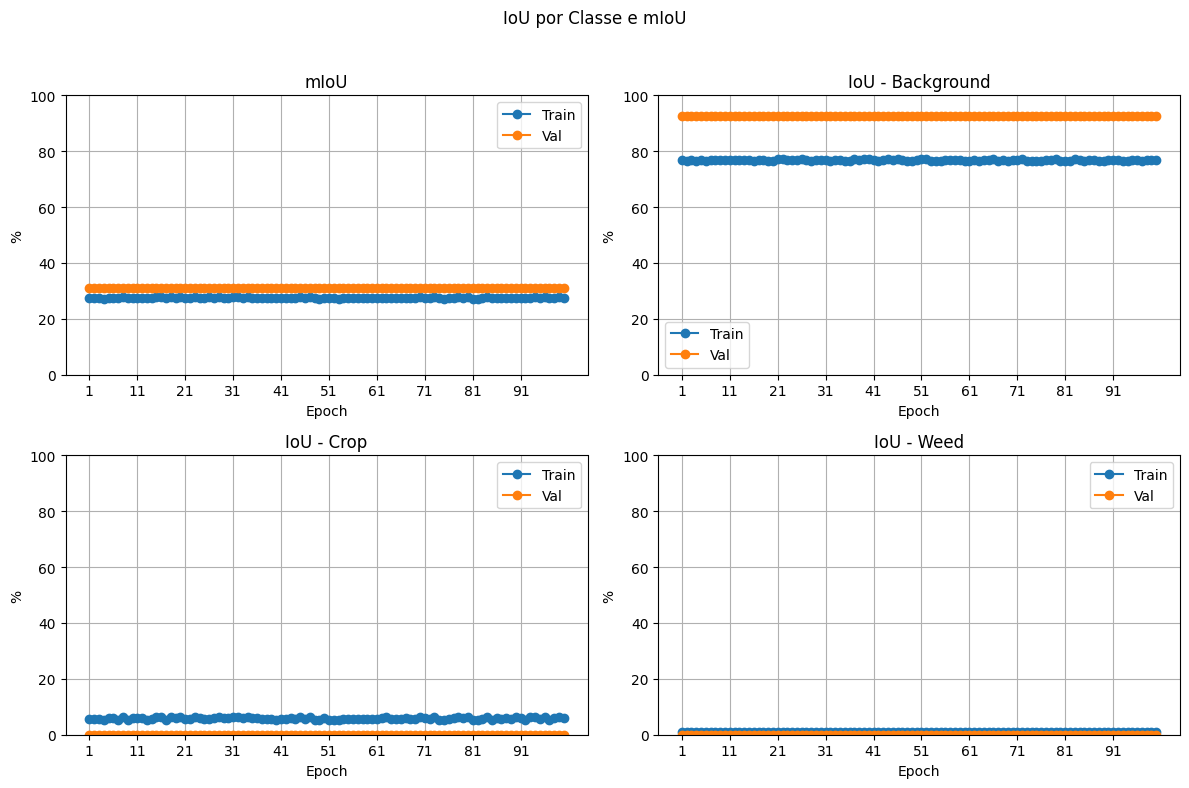

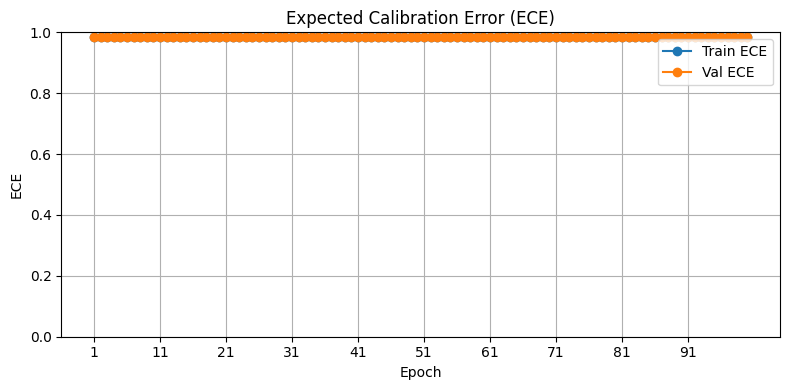

In [ ]:
# Define passo nos ticks do eixo X
xtick_step = 10
xtick_labels = list(range(min(epochs), max(epochs)+1, xtick_step))

# Cria figura com 4 subplots (2x2)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("IoU por Classe e mIoU")

# Subplot 1 - mIoU
axs[0, 0].plot(epochs, train_miou, label='Train', marker='o')
axs[0, 0].plot(epochs, val_miou, label='Val', marker='o')
axs[0, 0].set_title('mIoU')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('%')
axs[0, 0].set_xticks(xtick_labels)
axs[0, 0].set_ylim(0, 100)
axs[0, 0].legend()
axs[0, 0].grid(True)

# Subplot 2 - IoU BG
axs[0, 1].plot(epochs, train_iou_bg, label='Train', marker='o')
axs[0, 1].plot(epochs, val_iou_bg, label='Val', marker='o')
axs[0, 1].set_title('IoU - Background')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('%')
axs[0, 1].set_xticks(xtick_labels)
axs[0, 1].set_ylim(0, 100)
axs[0, 1].legend()
axs[0, 1].grid(True)

# Subplot 3 - IoU Crop
axs[1, 0].plot(epochs, train_iou_crop, label='Train', marker='o')
axs[1, 0].plot(epochs, val_iou_crop, label='Val', marker='o')
axs[1, 0].set_title('IoU - Crop')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('%')
axs[1, 0].set_xticks(xtick_labels)
axs[1, 0].set_ylim(0, 100)
axs[1, 0].legend()
axs[1, 0].grid(True)

# Subplot 4 - IoU Weed
axs[1, 1].plot(epochs, train_iou_weed, label='Train', marker='o')
axs[1, 1].plot(epochs, val_iou_weed, label='Val', marker='o')
axs[1, 1].set_title('IoU - Weed')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('%')
axs[1, 1].set_xticks(xtick_labels)
axs[1, 1].set_ylim(0, 100)
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Gráfico separado para ECE
plt.figure(figsize=(8, 4))
plt.plot(epochs, ece_train, label='Train ECE', marker='o')
plt.plot(epochs, ece_val, label='Val ECE', marker='o')
plt.title("Expected Calibration Error (ECE)")
plt.xlabel("Epoch")
plt.ylabel("ECE")
plt.xticks(xtick_labels)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
